<a href="https://colab.research.google.com/github/jahnavineelam/DeepLearning_Neural_Networks/blob/main/DL_LAB2_23035/exercise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Clear previous models
tf.keras.backend.clear_session()

# Fix random seed
np.random.seed(42)
tf.random.set_seed(42)

# AND Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=np.float32)

# Function to create identical models
def create_model(loss_function):

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(
            4,
            activation='sigmoid'
        ),
        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss=loss_function,
        metrics=['accuracy']
    )

    return model

# Model A (MSE)
model_mse = create_model('mean_squared_error')

history_mse = model_mse.fit(
    X,
    y,
    epochs=1500,
    verbose=0
)

# Reset seed again
tf.random.set_seed(42)

# Model B (BCE)
model_bce = create_model('binary_crossentropy')

history_bce = model_bce.fit(
    X,
    y,
    epochs=1500,
    verbose=0
)

In [ ]:
loss_mse, acc_mse = model_mse.evaluate(X, y, verbose=0)

loss_bce, acc_bce = model_bce.evaluate(X, y, verbose=0)

print("Model A (MSE)")
print("----------------------------")
print(f"Loss     : {loss_mse:.4f}")
print(f"Accuracy : {acc_mse*100:.2f}%")

print()

print("Model B (BCE)")
print("----------------------------")
print(f"Loss     : {loss_bce:.4f}")
print(f"Accuracy : {acc_bce*100:.2f}%")

Model A (MSE)
----------------------------
Loss     : 0.0002
Accuracy : 100.00%

Model B (BCE)
----------------------------
Loss     : 0.0030
Accuracy : 100.00%


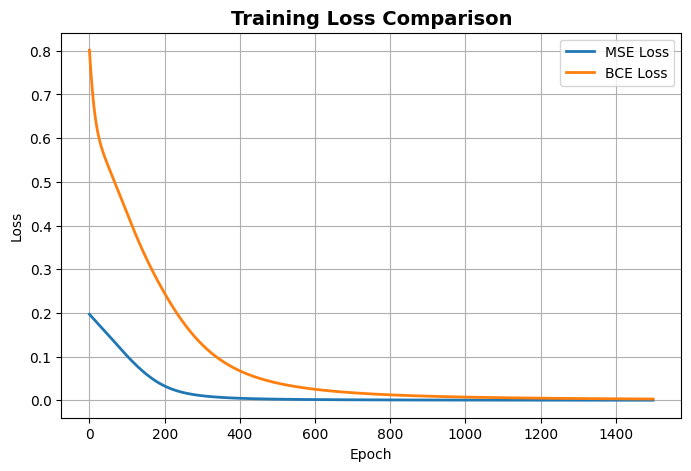

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mse.history['loss'],
    label='MSE Loss',
    linewidth=2
)

plt.plot(
    history_bce.history['loss'],
    label='BCE Loss',
    linewidth=2
)

plt.title(
    "Training Loss Comparison",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()